# CUSTOM DATASET FOR KITTI

In [63]:
# Dataset skeleton
from pathlib import Path
import numpy as np

class KittiDataset:

    def __init__(self, root, split="training"):
        self.root = Path(root)
        self.split = split

        self.velodyne_dir = self.root / split / "velodyne"
        self.label_dir = self.root / split / "label_2"
        self.calib_dir = self.root / split / "calib"

        # find all lidar files in self.velodyne_dir
        self.sample_ids = sorted(
            p.stem for p in self.velodyne_dir.glob("*.bin")
        )


    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]

        return {
            "id" : sample_id,
            "points" : self.load_velodyne(sample_id),
            "calib" : self.load_calibration(sample_id),
            "labels" : self.load_labels(sample_id)
        }

    # defining all load_* methods

    def load_velodyne(self, sample_id):
        path = self.velodyne_dir / f'{sample_id}.bin'

        raw = np.fromfile(path, dtype=np.float32)
        # reshape to (x,y,z) and internsity
        points = raw.reshape(-1,4)

        return points

    def bev_projection(self, points):
        POINT_CLOUD_RANGE = {
                        "x" : (0, 70),
                        "y" : (-40, 40),
                        "z" : (-3, 1)
                    }
        VOXEL_SIZE = (0.2, 0.2, 0.2)
        x_min, x_max = POINT_CLOUD_RANGE["x"]
        y_min, y_max = POINT_CLOUD_RANGE["y"]
        z_min, z_max = POINT_CLOUD_RANGE["z"]

        mask = (
            (points[:, 0] >= x_min) & (points[:, 0] < x_max) &
            (points[:, 1] >= y_min) & (points[:, 1] < y_max) &
            (points[:, 2] >= z_min) & (points[:, 2] < z_max)
        )

        points = points[mask]

        # Number of cells
        grid_x = int((x_max - x_min) / VOXEL_SIZE[0])
        grid_y = int((y_max - y_min) / VOXEL_SIZE[1])

        x_indices = ((points[:, 0] - x_min) / VOXEL_SIZE[0]).astype(np.int32)
        y_indices = ((points[:, 1] - y_min) / VOXEL_SIZE[1]).astype(np.int32)

        # Create channels
        height_bev = np.zeros((grid_x, grid_y), dtype=np.float32)
        density_bev = np.zeros((grid_x, grid_y), dtype=np.float32)
        intensity_bev = np.zeros((grid_x, grid_y), dtype=np.float32)

        
        for x_idx, y_idx, z in zip(x_indices, y_indices, points[:, 2]):
            # normalize height
            height = (z - z_min) / (z_max - z_min)
            height_bev[x_idx, y_idx] = max(height_bev[x_idx, y_idx], height)

    
        for x_idx, y_idx in zip(x_indices, y_indices):
            density_bev[x_idx, y_idx] += 1

        # normalize density
        density_bev = np.minimum(density_bev, 64)
        density_bev = np.log1p(density_bev) / np.log(65)

        for x_idx, y_idx, intensity in zip(x_indices, y_indices, points[:, 3]):
            intensity_bev[x_idx, y_idx] = max(intensity_bev[x_idx, y_idx], intensity)

        bev = np.stack([
            height_bev,
            density_bev,
            intensity_bev
        ], axis=0)

        return bev


    
    def load_calibration(self, sample_id):
        path = self.calib_dir / f'{sample_id}.txt'

        with open(path) as f:
            lines = f.readlines()
    
        p2 = lines[2].strip().split()[1:]
        r0_rect = lines[4].strip().split()[1:]
        tr_velo_to_cam = lines[5].strip().split()[1:]
    
        # velo to cam- first tranformation
        tr_velo_to_cam = np.array(tr_velo_to_cam, dtype=np.float32).reshape(3, 4)
    
        # cam to rectified cam- second transformation
        r0_rect = np.array(r0_rect, dtype=np.float32).reshape(3, 3)
    
        # to 2d image- prjection
        p2 = np.array(p2, dtype=np.float32).reshape(3, 4)
    
        return {
            "p2" : p2,
            "r0_rect" : r0_rect,
            "tr_velo_to_cam" : tr_velo_to_cam
        }


    def load_labels(self, sample_id):
        path = self.label_dir / f'{sample_id}.txt'
        objects = []

        with open(path) as f:
            for line in f:
                label = line.strip().split()
                object_type = label[0]
                bbox = np.array([float(label[4]), float(label[5]), float(label[6]), float(label[7])])
                dimensions = np.array([float(label[8]), float(label[9]), float(label[10])])
                location = np.array([float(label[11]), float(label[12]), float(label[13])])
                rotation_y = float(label[14])
    
                objects.append({"type": object_type, "bbox": bbox, "dimensions": dimensions, 
                                "location": location, "rotation_y": rotation_y})
    
        return objects

In [64]:
dataset = KittiDataset("../data/KITTI")

sample = dataset[0]

points = sample["points"]
bev = dataset.bev_projection(points)

print("Sample:", sample["id"])
print("Points:", points.shape)
print("BEV:", bev.shape)

print("Height range:",
      bev[0].min(),
      bev[0].max())

print("Density range:",
      bev[1].min(),
      bev[1].max())

print("Intensity range:",
      bev[2].min(),
      bev[2].max())

Sample: 000000
Points: (115384, 4)
BEV: (3, 350, 400)
Height range: 0.0 0.999750018119812
Density range: 0.0 1.0000000443396655
Intensity range: 0.0 0.9900000095367432


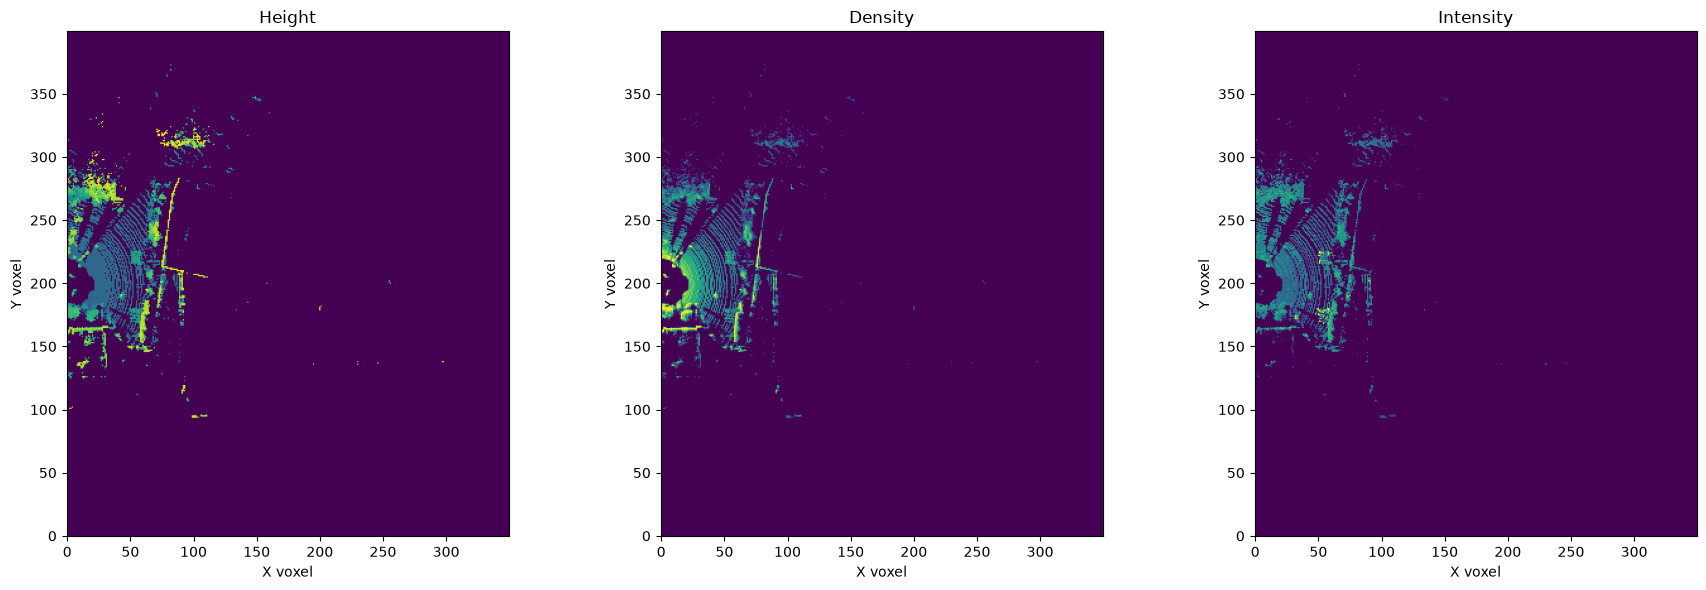

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Height
axes[0].imshow(
    bev[0].T,
    origin="lower",
    aspect="equal"
)
axes[0].set_title("Height")
axes[0].set_xlabel("X voxel")
axes[0].set_ylabel("Y voxel")

# Density
axes[1].imshow(
    bev[1].T,
    origin="lower",
    aspect="equal"
)
axes[1].set_title("Density")
axes[1].set_xlabel("X voxel")
axes[1].set_ylabel("Y voxel")

# Intensity
axes[2].imshow(
    bev[2].T,
    origin="lower",
    aspect="equal"
)
axes[2].set_title("Intensity")
axes[2].set_xlabel("X voxel")
axes[2].set_ylabel("Y voxel")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000443396655].


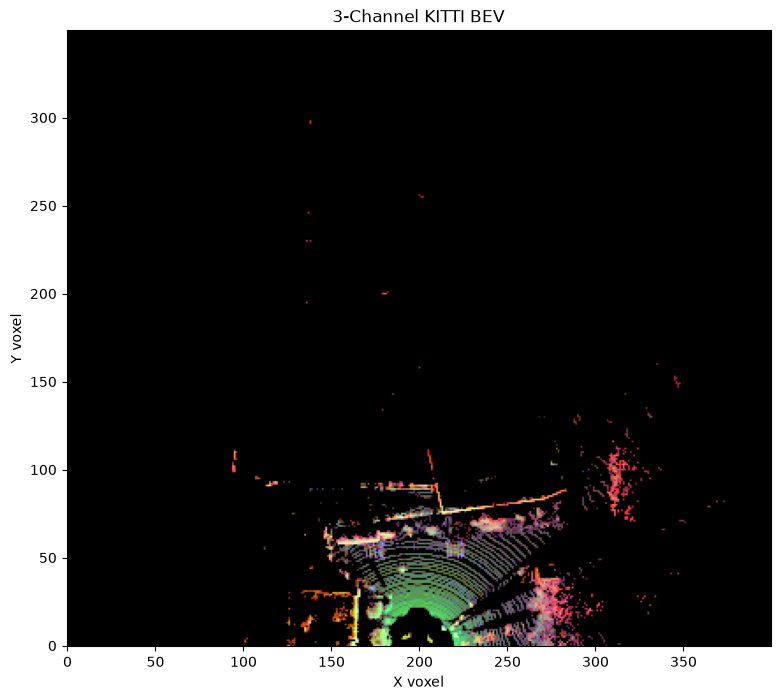

In [66]:
bev_rgb = np.transpose(bev, (1, 2, 0))

plt.figure(figsize=(10, 8))

plt.imshow(
    bev_rgb,
    origin="lower",
    aspect="equal"
)

plt.xlabel("X voxel")
plt.ylabel("Y voxel")
plt.title("3-Channel KITTI BEV")

plt.show()

In [44]:
# creating a dataset
dataset = KittiDataset(
    root="../data/KITTI"
)

In [45]:
len(dataset)

7481

In [46]:
sample = dataset[0]

In [47]:
print(sample["id"])

000000


In [48]:
sample.keys()

dict_keys(['id', 'points', 'calib', 'labels'])

In [49]:
points = sample["points"]

print(points.shape)

(115384, 4)


In [50]:
calib = sample["calib"]

print(calib.keys())

dict_keys(['p2', 'r0_rect', 'tr_velo_to_cam'])


In [51]:
print(calib["tr_velo_to_cam"].shape)
print(calib["r0_rect"].shape)
print(calib["p2"].shape)

(3, 4)
(3, 3)
(3, 4)


In [52]:
labels = sample["labels"]

print(len(labels))

1


In [53]:
for obj in labels:
    print(
        obj["type"],
        obj["bbox"],
        obj["dimensions"],
        obj["location"],
        obj["rotation_y"]
    )

Pedestrian [712.4  143.   810.73 307.92] [1.89 0.48 1.2 ] [1.84 1.47 8.41] 0.01


In [54]:
points = dataset[0]["points"]

xyz = points[:, :3]

print("X range:", xyz[:, 0].min(), xyz[:, 0].max())
print("Y range:", xyz[:, 1].min(), xyz[:, 1].max())
print("Z range:", xyz[:, 2].min(), xyz[:, 2].max())

X range: -71.036 73.039
Y range: -21.105 53.797
Z range: -5.16 2.672


In [55]:
points

array([[ 1.8324e+01,  4.9000e-02,  8.2900e-01,  0.0000e+00],
       [ 1.8344e+01,  1.0600e-01,  8.2900e-01,  0.0000e+00],
       [ 5.1299e+01,  5.0500e-01,  1.9440e+00,  0.0000e+00],
       ...,
       [ 3.7180e+00, -1.4060e+00, -1.7370e+00,  3.4000e-01],
       [ 3.7140e+00, -1.3910e+00, -1.7330e+00,  4.1000e-01],
       [ 3.9670e+00, -1.4740e+00, -1.8570e+00,  0.0000e+00]],
      shape=(115384, 4), dtype=float32)

In [56]:
POINT_CLOUD_RANGE = {
    "x" : (0, 70),
    "y" : (-40, 40),
    "z" : (-3, 1)
}

def filter_points(points, points_cloud_range):
    x_min, x_max = points_cloud_range["x"]
    y_min, y_max = points_cloud_range["y"]
    z_min, z_max = points_cloud_range["z"]

    mask = (
        (points[:, 0] >= x_min) &
        (points[:, 0] <= x_max) &
        (points[:, 1] >= y_min) &
        (points[:, 1] <= y_max) &
        (points[:, 2] >= z_min) &
        (points[:, 2] <= z_max)
    )

    return points[mask]

In [57]:
filtered_points = filter_points(
    points,
    POINT_CLOUD_RANGE
)

print("Original:", points.shape)
print("Filtered:", filtered_points.shape)

Original: (115384, 4)
Filtered: (62853, 4)


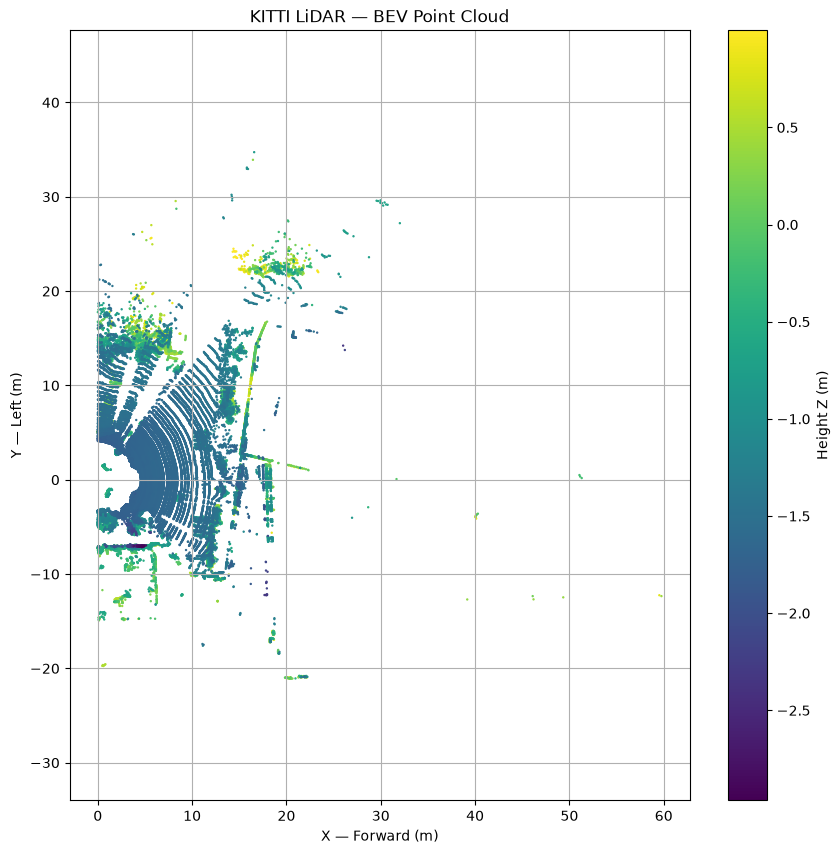

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

plt.scatter(
    filtered_points[:, 0],
    filtered_points[:, 1],
    s=0.5,
    c=filtered_points[:, 2],
    cmap="viridis"
)

plt.xlabel("X — Forward (m)")
plt.ylabel("Y — Left (m)")
plt.title("KITTI LiDAR — BEV Point Cloud")

plt.axis("equal")
plt.grid()

plt.colorbar(label="Height Z (m)")

plt.show()

In [59]:

VOXEL_SIZE = (0.2, 0.2, 0.2)

def create_bev(points, point_cloud_range, voxel_size):

    x_min, x_max = point_cloud_range["x"]
    y_min, y_max = point_cloud_range["y"]

    voxel_x, voxel_y, _ = voxel_size

    # Number of cells
    grid_x = int((x_max - x_min) / voxel_x)
    grid_y = int((y_max - y_min) / voxel_y)

    # Create occupancy grid
    bev = np.zeros((grid_x, grid_y), dtype=np.float32)

    # Convert coordinates to grid indices
    x_indices = ((points[:, 0] - x_min) / voxel_x).astype(np.int32)
    y_indices = ((points[:, 1] - y_min) / voxel_y).astype(np.int32)

    # Keep valid indices
    mask = (
        (x_indices >= 0) &
        (x_indices < grid_x) &
        (y_indices >= 0) &
        (y_indices < grid_y)
    )

    x_indices = x_indices[mask]
    y_indices = y_indices[mask]

    # Mark occupied cells
    bev[x_indices, y_indices] = 1

    return bev

bev = create_bev(
    filtered_points,
    POINT_CLOUD_RANGE,
    VOXEL_SIZE
)

print("BEV shape:", bev.shape)

BEV shape: (350, 400)


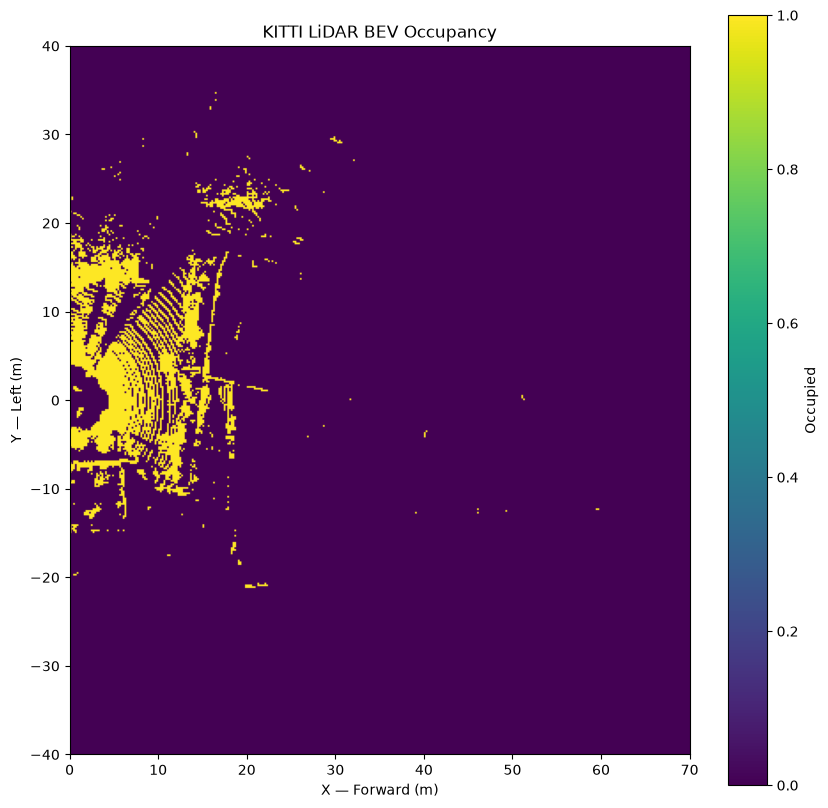

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

plt.imshow(
    bev.T,
    origin="lower",
    extent=[
        POINT_CLOUD_RANGE["x"][0],
        POINT_CLOUD_RANGE["x"][1],
        POINT_CLOUD_RANGE["y"][0],
        POINT_CLOUD_RANGE["y"][1]
    ],
    aspect="equal"
)

plt.xlabel("X — Forward (m)")
plt.ylabel("Y — Left (m)")
plt.title("KITTI LiDAR BEV Occupancy")

plt.colorbar(label="Occupied")

plt.show()

In [ ]:
POINT_CLOUD_RANGE = {
                        "x" : (0, 70),
                        "y" : (-40, 40),
                        "z" : (-3, 1)
                    }
VOXEL_SIZE = (0.2, 0.2, 0.2)
x_min, x_max = POINT_CLOUD_RANGE["x"]
y_min, y_max = POINT_CLOUD_RANGE["y"]
z_min, z_max = POINT_CLOUD_RANGE["z"]

# Number of cells
grid_x = int((x_max - x_min) / VOXEL_SIZE[0])
grid_y = int((y_max - y_min) / VOXEL_SIZE[1])

x_indices = ((points[:, 0] - x_min) / VOXEL_SIZE[0]).astype(np.int32)
y_indices = ((points[:, 0] - y_min) / VOXEL_SIZE[1]).astype(np.int32)

# Create channels
height_bev = np.zeros((grid_x, grid_y), dtype=np.float32)
density_bev = np.zeros((grid_x, grid_y), dtype=np.float32)
intensity_bev = np.zeros((grid_x, grid_y), dtype=np.float32)

for x_idx, y_idx, z in zip(x_indices, y_indices, points[:, 2]):
    height_bev[x_idx, y_idx] = max(height_bev[x_idx, y_idx], z)

for x_idx, y_idx, z in zip(x_indices, y_indices):
    density_bev[x_idx, y_idx] += 1

# normalize density
density_bev = np.minimum(density_bev, 64)
density_bev = np.log1p(density_bev) / np.log(65)

for x_idx, y_idx, z in zip(x_indices, y_indices, points[:, 3]):
    intensity_bev[x_idx, y_idx] = max(intensity_bev[x_idx, y_idx], z)

bev = np.stack([
    height_bev,
    density_bev,
    intensity_bev
], axis=0)

print(bev.shape)

350 400


IndexError: index 456 is out of bounds for axis 1 with size 400